# Module 1 — 酒店信息画像构建 演示

**目标**：搞清楚每个酒店「已知什么、缺什么、什么过时了」

流程：
1. 读取 6000 条 Expedia 真实评论 + 13 家酒店官方描述
2. 用关键词匹配抽取每条评论覆盖的维度（20个维度，4个类别）
3. 用官方描述数据补充 policy 类维度
4. 输出每家酒店的信息完整度 + 优先缺口列表

In [10]:
# 如果缺包就跑这格，装完 restart kernel
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "pandas", "matplotlib", "python-dotenv", "-q"])

CompletedProcess(args=['/Users/jasondai/Library/Mobile Documents/com~apple~CloudDocs/Desktop/UPenn/Courses/CIS 5800/homework_1/.venv/bin/python', '-m', 'pip', 'install', 'pandas', 'matplotlib', 'python-dotenv', '-q'], returncode=0)

In [11]:
import json, sys, os
from pathlib import Path
import pandas as pd

# 确保能 import module1
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

# 加载已生成的 hotel_profiles.json
PROFILES_PATH = ROOT / "output" / "hotel_profiles.json"
with open(PROFILES_PATH) as f:
    profiles = json.load(f)

print(f"✅ 加载完成：{len(profiles)} 家酒店")
print(f"   每家酒店覆盖 {len(next(iter(profiles.values()))['profile'])} 个维度")

✅ 加载完成：13 家酒店
   每家酒店覆盖 20 个维度


## 1. 所有酒店信息完整度一览

In [12]:
rows = []
for pid, data in profiles.items():
    c = data["completeness"]
    gaps = data["gaps"]
    top = gaps[0] if gaps else {}
    rows.append({
        "Hotel ID (短)": pid[:16] + "…",
        "完整度": c["completeness_score"],          # 存数字，不加 %
        "评论覆盖维度": c["review_covered_dimensions"],
        "总覆盖维度": c["covered_dimensions"],
        "总维度": c["total_dimensions"],
        "缺口数量": len(gaps),
        "最高优先缺口": top.get("label", "—"),
        "原因": top.get("reason", "—"),
    })

df_summary = pd.DataFrame(rows)
df_summary.style\
    .background_gradient(subset=["完整度"], cmap="RdYlGn")\
    .format({"完整度": "{:.1f}%"})

,Hotel ID (短),完整度,评论覆盖维度,总覆盖维度,总维度,缺口数量,最高优先缺口,原因
0,110f01b8ae518a0e…,80.0%,13,16,20,8,Breakfast Hours,never_mentioned
1,3216b1b7885bffdb…,90.0%,15,18,20,10,Breakfast Hours,never_mentioned
2,3b984f3ba8df55b2…,75.0%,12,15,20,17,Breakfast Hours,never_mentioned
3,5f5a0cd8662f0ddf…,50.0%,2,10,20,12,Air Conditioning / Heating,never_mentioned
4,7d027ef72c02eaa1…,95.0%,19,19,20,14,Elevator,official_conflict
5,823fb2499b4e37d9…,95.0%,17,19,20,9,Power Outlets & Charging,never_mentioned
6,9a0043fd4258a128…,75.0%,11,15,20,16,Air Conditioning / Heating,never_mentioned
7,a036cbe1d9fbf9cb…,60.0%,7,12,20,15,Air Conditioning / Heating,never_mentioned
8,db38b19b897dbece…,95.0%,19,19,20,13,Elevator,official_conflict
9,e52d67a758ce4ad0…,85.0%,13,17,20,9,Breakfast Hours,never_mentioned


## 2. 单酒店维度热力图

选一家评论多、有代表性的酒店深入看（Courtyard by Marriott Airport）

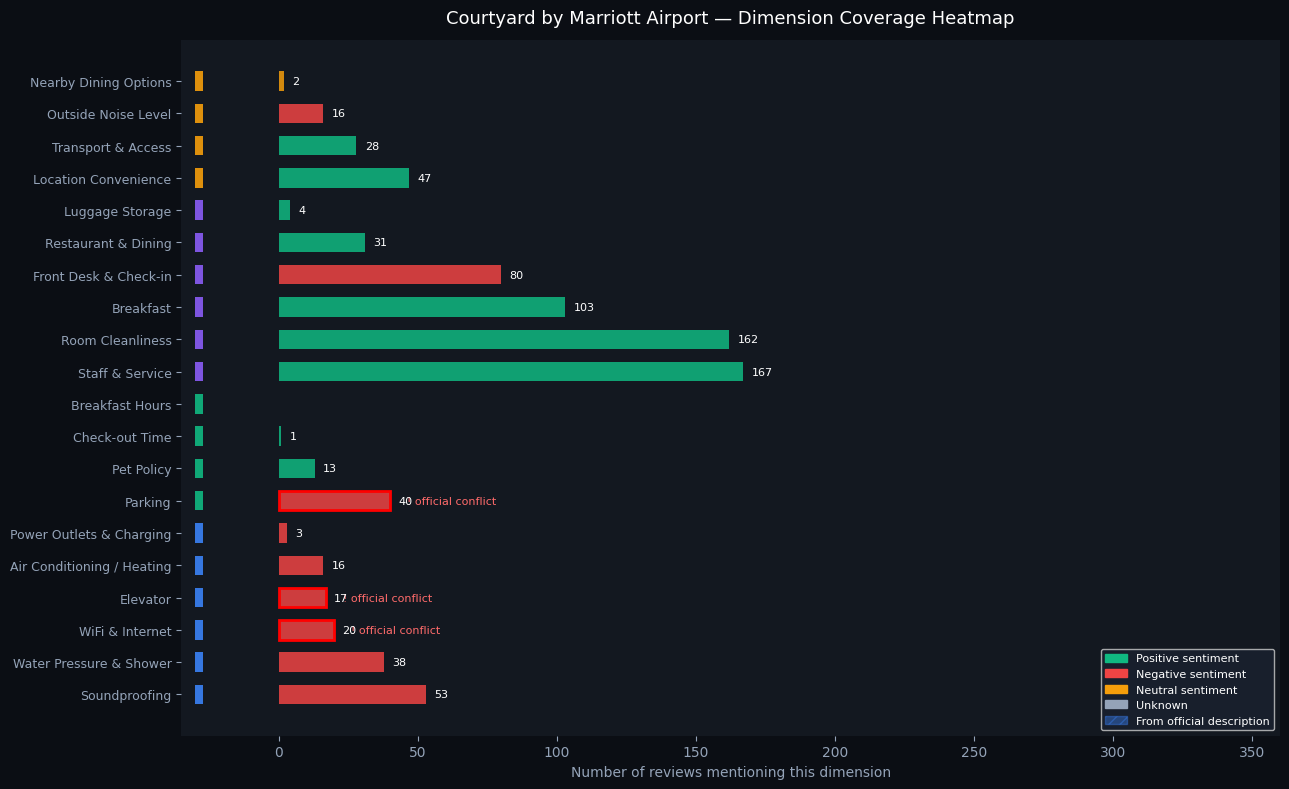

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

TARGET_PREFIX = "7d027ef7"
pid = next(p for p in profiles if p.startswith(TARGET_PREFIX))
profile = profiles[pid]["profile"]

import pandas as pd
dim_rows = []
for dim, info in profile.items():
    sentiment = info["dominant_sentiment"] or "unknown"
    dim_rows.append({
        "dimension": info["label"],
        "category":  info["category"],
        "mention_count": info["mention_count"],
        "sentiment": sentiment,
        "has_official": info.get("has_official_info", False),
        "conflict":  info.get("official_conflict", False),
    })

df = pd.DataFrame(dim_rows).sort_values(["category", "mention_count"], ascending=[True, False])

SENT_COLOR = {"positive": "#10B981", "negative": "#EF4444", "neutral": "#F59E0B", "unknown": "#94A3B8"}
CAT_COLOR  = {"hardware": "#3B82F6", "service": "#8B5CF6", "surroundings": "#F59E0B", "policy": "#10B981"}

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor("#0B0E14")
ax.set_facecolor("#131820")

for i, (_, row) in enumerate(df.iterrows()):
    count     = row["mention_count"]
    color     = SENT_COLOR[row["sentiment"]]
    bar_width = min(count, 300)

    ax.barh(i, bar_width, color=color, alpha=0.85, height=0.6)

    if row["conflict"]:
        ax.barh(i, max(bar_width, 5), color="none", edgecolor="#FF0000", linewidth=2, height=0.6)
        ax.text(bar_width + 6, i, "! official conflict", color="#FF6B6B", va="center", fontsize=8)
    elif row["has_official"] and count == 0:
        ax.barh(i, 8, color="#3B82F6", alpha=0.4, height=0.6, hatch="///")
        ax.text(14, i, "official data known", color="#3B82F6", va="center", fontsize=8)

    if count > 0:
        ax.text(bar_width + 3, i, str(count), color="white", va="center", fontsize=8)

    ax.barh(i, 3, left=-30, color=CAT_COLOR[row["category"]], height=0.6, alpha=0.9)

ax.set_yticks(range(len(df)))
ax.set_yticklabels(df["dimension"].tolist(), color="white", fontsize=9)
ax.set_xlabel("Number of reviews mentioning this dimension", color="#94A3B8")
ax.set_title("Courtyard by Marriott Airport — Dimension Coverage Heatmap", color="white", fontsize=13, pad=12)
ax.tick_params(colors="#94A3B8")
ax.spines[:].set_visible(False)
ax.set_xlim(-35, 360)

legend_patches = [
    mpatches.Patch(color="#10B981", label="Positive sentiment"),
    mpatches.Patch(color="#EF4444", label="Negative sentiment"),
    mpatches.Patch(color="#F59E0B", label="Neutral sentiment"),
    mpatches.Patch(color="#94A3B8", label="Unknown"),
    mpatches.Patch(color="#3B82F6", alpha=0.4, hatch="///", label="From official description"),
]
ax.legend(handles=legend_patches, loc="lower right", facecolor="#1A2230", labelcolor="white", fontsize=8)

plt.tight_layout()
plt.show()

## 3. 优先缺口列表（Module 2 的输入）

这就是 Module 2 用来决定「问哪个问题」的数据

In [14]:
REASON_EMOJI = {
    "official_conflict": "🔴",
    "never_mentioned":   "🟠",
    "stale":             "🟡",
    "conflicting":       "🟢",
}

gaps = profiles[pid]["gaps"]
gap_rows = []
for g in gaps:
    gap_rows.append({
        "Priority": REASON_EMOJI.get(g["reason"], "⚪") + f" P{g['priority']}",
        "Dimension": g["label"],
        "Category": g["category"],
        "Reason": g["reason"],
        "Detail": g["reason_label"],
        "# Reviews": g["mention_count"],
        "Last Seen": g["last_mentioned"] or "—",
        "Official Info": (g.get("official_info") or "")[:60] + ("…" if len(g.get("official_info") or "") > 60 else ""),
    })

df_gaps = pd.DataFrame(gap_rows)
df_gaps.style.map(
    lambda v: "background-color: #3d0000; color: #ff8080" if "🔴" in str(v) else
              "background-color: #3d2000; color: #ffb347" if "🟠" in str(v) else
              "background-color: #3d3000; color: #ffd700" if "🟡" in str(v) else "",
    subset=["Priority"]
)

,Priority,Dimension,Category,Reason,Detail,# Reviews,Last Seen,Official Info
0,🔴 P4,Elevator,hardware,official_conflict,Official info conflicts with reviews (9 negative),17,2024-06-05,elevator; wheelchair-accessible path to elevator
1,🔴 P4,Parking,policy,official_conflict,Official info conflicts with reviews (18 negative),40,2026-01-30,free uncovered self parking on site; limited onsite parking …
2,🔴 P4,WiFi & Internet,hardware,official_conflict,Official info conflicts with reviews (10 negative),20,2024-02-27,available in all rooms: free wifi; available in some public …
3,🟠 P3,Breakfast Hours,policy,never_mentioned,No data yet,0,—,
4,🟡 P2,Check-out Time,policy,stale,Last mentioned 10 months ago,1,2025-06-16,Check-out by 11:00 AM; Check-out before 11:00 AM; Express ch…
5,🟡 P2,Nearby Dining Options,surroundings,stale,Last mentioned 10 months ago,2,2025-06-16,
6,🟡 P2,Power Outlets & Charging,hardware,stale,Last mentioned 32 months ago,3,2023-08-08,
7,🟢 P1,Air Conditioning / Heating,hardware,conflicting,Mixed reviews — 6 positive / 8 negative,16,2026-02-06,
8,🟢 P1,Front Desk & Check-in,service,conflicting,Mixed reviews — 32 positive / 36 negative,80,2026-01-30,Check-in: 3:00 PM – midnight; front desk staff will greet gu…
9,🟢 P1,Outside Noise Level,surroundings,conflicting,Mixed reviews — 5 positive / 10 negative,16,2026-02-06,


## 4. 真实评论证据

看看每个维度具体是哪些评论支撑了这个结论

In [15]:
SHOW_DIMS = ["wifi_speed", "parking", "elevator", "room_cleanliness", "staff_friendliness"]

for dim in SHOW_DIMS:
    info     = profile[dim]
    snippets = info["example_snippets"]
    sentiment = info["dominant_sentiment"] or "unknown"
    icon = {"positive": "✅", "negative": "❌", "neutral": "➖", "unknown": "❓"}[sentiment]

    print(f"{icon} [{info['category'].upper()}] {info['label']}  —  {info['mention_count']} reviews  —  sentiment: {sentiment}")

    if info.get("official_info"):
        print(f"   📋 Official: {info['official_info'][:100]}")
    if info.get("official_conflict"):
        print(f"   ⚠️  CONFLICT: official description contradicts review sentiment!")

    for s in snippets[:2]:
        print(f"   💬 \"{s[:120]}\"")
    print()

❌ [HARDWARE] WiFi & Internet  —  20 reviews  —  sentiment: negative
   📋 Official: available in all rooms: free wifi; available in some public areas: free wifi; in-room wifi speed: 25
   ⚠️  CONFLICT: official description contradicts review sentiment!
   💬 "wifi did not work to weak."
   💬 "they could not give us a do not disturb sign and the wi-fi didn't work in the evenings."

❌ [POLICY] Parking  —  40 reviews  —  sentiment: negative
   📋 Official: free uncovered self parking on site; limited onsite parking (max 1 space per unit); onsite parking i
   ⚠️  CONFLICT: official description contradicts review sentiment!
   💬 "the room smelled with a dehumidifier running in it the parking lot was small and hard to get back on the main road"
   💬 "my room was disgusting offered me another room when i got back from dinner but there was zero parking so i just left"

❌ [HARDWARE] Elevator  —  17 reviews  —  sentiment: negative
   📋 Official: elevator; wheelchair-accessible path to elevator
   ⚠

## 5. Module 1 → Module 2 交接数据格式

用户写完评论后，Module 2 会拿到这个结构，决定问什么

In [16]:
# 这就是 Module 2 收到的输入（top 5 gaps）
module2_input = {
    "property_id": pid,
    "top_gaps": profiles[pid]["top_gaps"],
}

print("Module 2 收到的缺口数据（JSON 格式）：\n")
print(json.dumps(module2_input, indent=2, ensure_ascii=False))

Module 2 收到的缺口数据（JSON 格式）：

{
  "property_id": "7d027ef72c02eaa17af3c993fd5dba50d17b41a6280389a46c13c7e2c32a5b06",
  "top_gaps": [
    {
      "dimension": "elevator",
      "label": "Elevator",
      "category": "hardware",
      "reason": "official_conflict",
      "reason_label": "Official info conflicts with reviews (9 negative)",
      "priority": 4,
      "mention_count": 17,
      "last_mentioned": "2024-06-05",
      "dominant_sentiment": "negative",
      "official_info": "elevator; wheelchair-accessible path to elevator"
    },
    {
      "dimension": "parking",
      "label": "Parking",
      "category": "policy",
      "reason": "official_conflict",
      "reason_label": "Official info conflicts with reviews (18 negative)",
      "priority": 4,
      "mention_count": 40,
      "last_mentioned": "2026-01-30",
      "dominant_sentiment": "negative",
      "official_info": "free uncovered self parking on site; limited onsite parking (max 1 space per unit); onsite parking incl